# Data Exploration — UK CAA Punctuality Statistics

Quick look at the raw data before modelling: what's in it, how delays are distributed, and which airports/airlines stand out.

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd

from src.load_data import load_raw_data
from src.preprocess import preprocess, compute_late_percent

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "figure.dpi": 120,
})

raw = load_raw_data()
df = preprocess(raw)
print(f"Raw rows: {len(raw):,} → After cleaning: {len(df):,}")
df.head(3)

Raw rows: 10,912 → After cleaning: 5,618


,run_date,reporting_period,reporting_airport,origin_destination_country,origin_destination,airline_name,arrival_departure,scheduled_charter,number_flights_matched,actual_flights_unmatched,...,flights_between_181_and_360_minutes_late_percent,flights_more_than_360_minutes_late_percent,flights_unmatched_percent,flights_cancelled_percent,average_delay_mins,previous_year_month_flights_matched,previous_year_month_early_to_15_mins_late_percent,previous_year_month_average_delay,late_percent,is_delayed
0,16/04/2025 09:47,202502,ABERDEEN,POLAND,GDANSK,WIZZ AIR,A,S,12,0,...,0.0,0.0,0.0,0.0,5.0,8,75.000000,10.0,8.333333,0
1,16/04/2025 09:47,202502,ABERDEEN,POLAND,GDANSK,WIZZ AIR,D,S,12,0,...,0.0,0.0,0.0,0.0,4.0,8,62.500000,20.0,8.333333,0
2,16/04/2025 09:47,202502,ABERDEEN,UNITED KINGDOM,BELFAST CITY (GEORGE BEST),LOGANAIR LTD,A,S,16,0,...,0.0,0.0,0.0,0.0,5.0,17,88.235294,7.0,12.500000,0


## Target distribution

Our binary target: a route is "delayed" when >50% of its flights were >15 minutes late. How imbalanced is this?

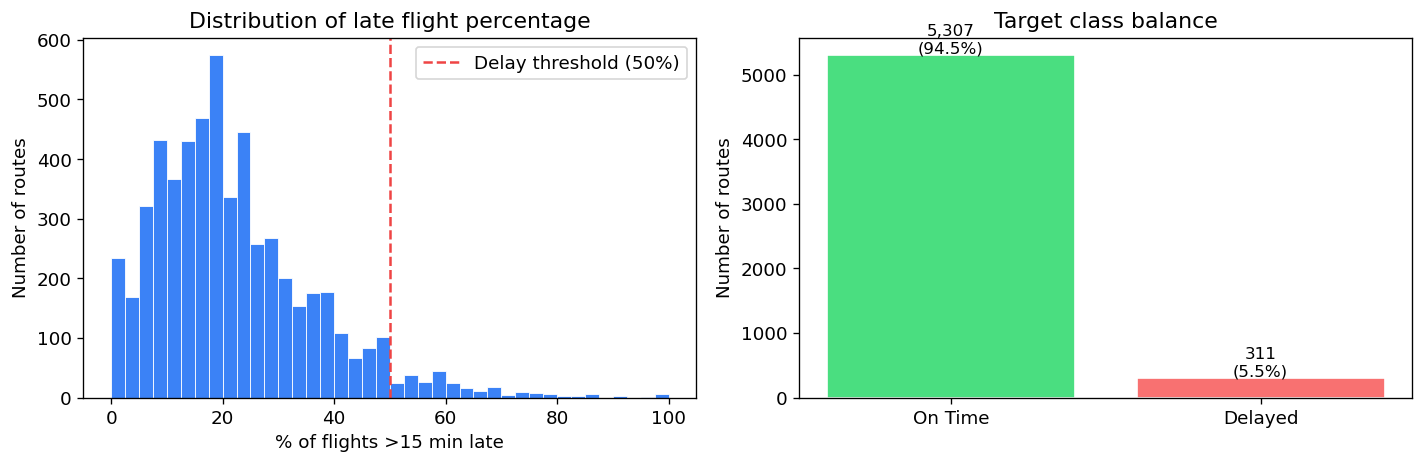

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of late_percent
axes[0].hist(df["late_percent"], bins=40, color="#3b82f6", edgecolor="white", linewidth=0.5)
axes[0].axvline(50, color="#ef4444", linestyle="--", linewidth=1.5, label="Delay threshold (50%)")
axes[0].set_xlabel("% of flights >15 min late")
axes[0].set_ylabel("Number of routes")
axes[0].set_title("Distribution of late flight percentage")
axes[0].legend()

# Right: target balance
counts = df["is_delayed"].value_counts()
labels = ["On Time", "Delayed"]
colors = ["#4ade80", "#f87171"]
axes[1].bar(labels, [counts[0], counts[1]], color=colors, edgecolor="white")
for i, v in enumerate([counts[0], counts[1]]):
    axes[1].text(i, v + 30, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=10)
axes[1].set_ylabel("Number of routes")
axes[1].set_title("Target class balance")

plt.tight_layout()
plt.show()

## Average delay by airport

Which UK airports have the worst average delays?

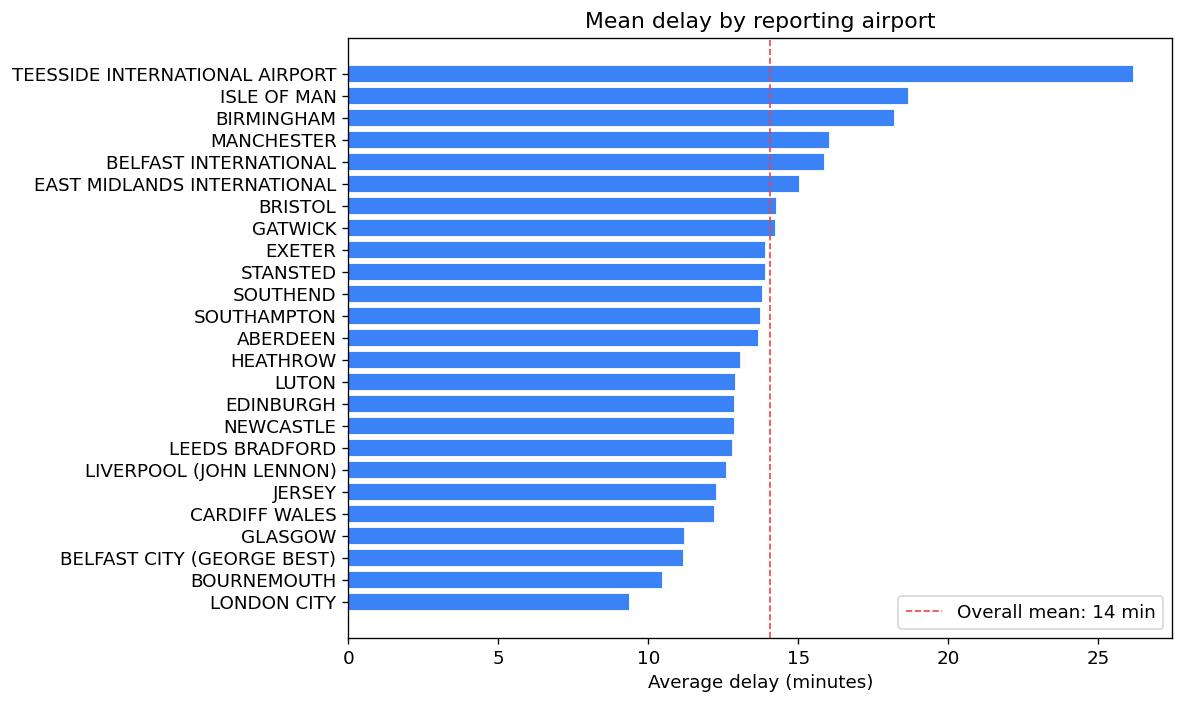

In [5]:
airport_delay = (
    df.groupby("reporting_airport")["average_delay_mins"]
    .mean()
    .dropna()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(airport_delay.index, airport_delay.values, color="#3b82f6", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Average delay (minutes)")
ax.set_title("Mean delay by reporting airport")
ax.axvline(airport_delay.mean(), color="#ef4444", linestyle="--", linewidth=1, label=f"Overall mean: {airport_delay.mean():.0f} min")
ax.legend()
plt.tight_layout()
plt.show()

## Delay rate by airport

What fraction of each airport's routes are classified as "delayed"?

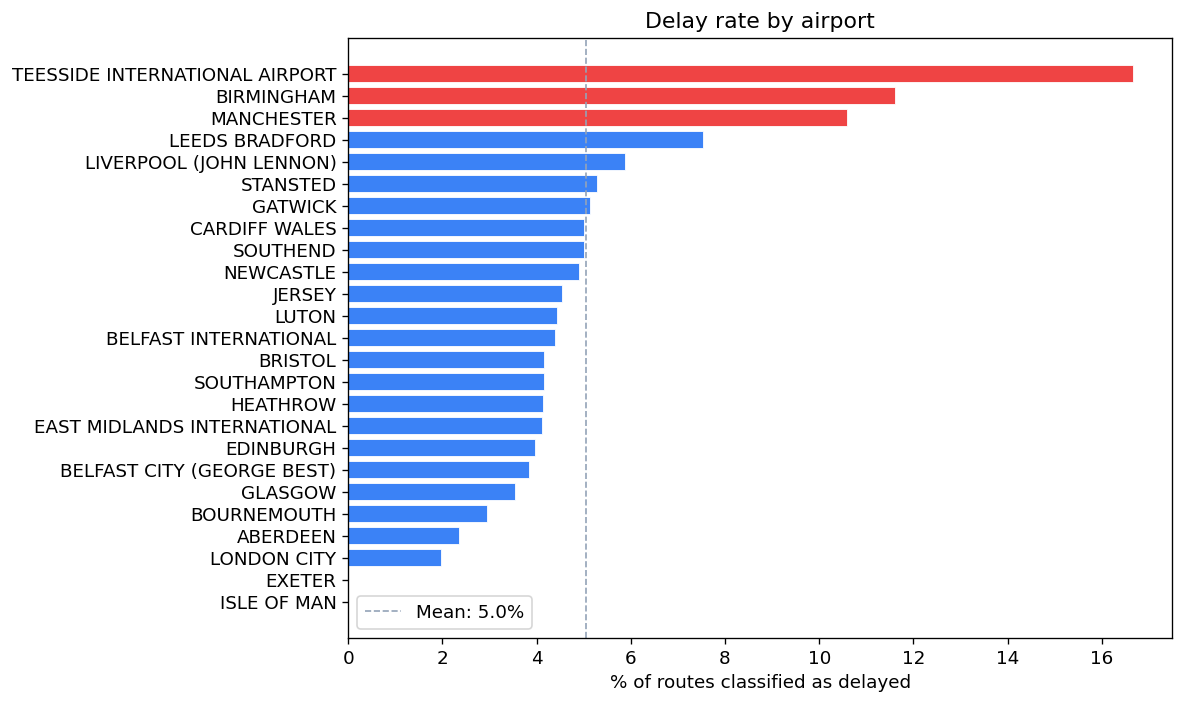

In [6]:
delay_rate = (
    df.groupby("reporting_airport")["is_delayed"]
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#ef4444" if v > 0.1 else "#3b82f6" for v in delay_rate.values]
ax.barh(delay_rate.index, delay_rate.values * 100, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("% of routes classified as delayed")
ax.set_title("Delay rate by airport")
ax.axvline(delay_rate.mean() * 100, color="#94a3b8", linestyle="--", linewidth=1, label=f"Mean: {delay_rate.mean()*100:.1f}%")
ax.legend()
plt.tight_layout()
plt.show()

## Top 15 airlines by delay rate

Which airlines have the highest proportion of delayed routes? (Minimum 20 routes to avoid noisy small samples.)

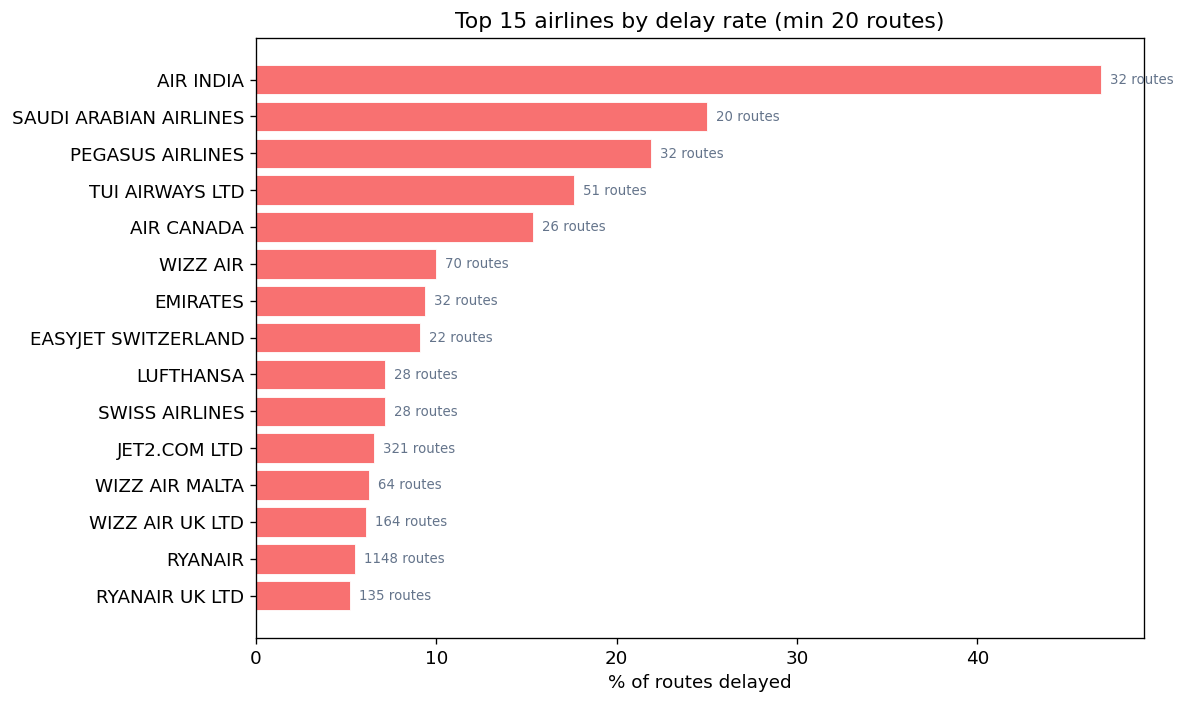

In [7]:
airline_stats = df.groupby("airline_name").agg(
    routes=("is_delayed", "size"),
    delay_rate=("is_delayed", "mean"),
    avg_delay=("average_delay_mins", "mean"),
)
airline_stats = airline_stats[airline_stats["routes"] >= 20].sort_values("delay_rate", ascending=False)

top = airline_stats.head(15).sort_values("delay_rate")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top.index, top["delay_rate"] * 100, color="#f87171", edgecolor="white", linewidth=0.5)
ax.set_xlabel("% of routes delayed")
ax.set_title("Top 15 airlines by delay rate (min 20 routes)")

# Annotate with route count
for i, (name, row) in enumerate(top.iterrows()):
    ax.text(row["delay_rate"] * 100 + 0.5, i, f'{row["routes"]:.0f} routes', va="center", fontsize=8, color="#64748b")

plt.tight_layout()
plt.show()

## Arrival vs departure delays

Are arrivals or departures more likely to be delayed?

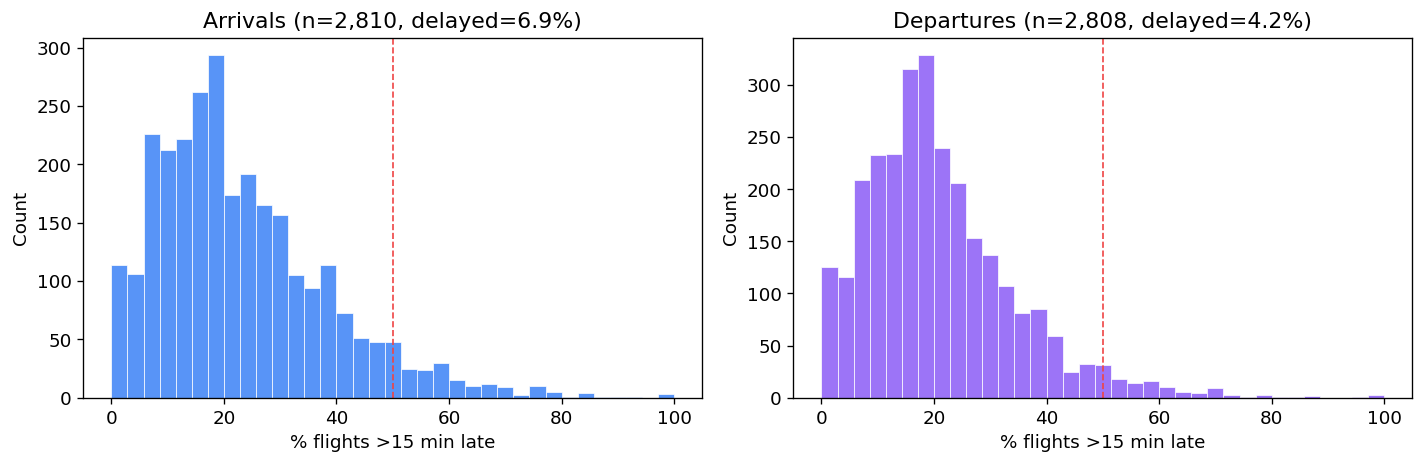

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, (label, group) in enumerate(df.groupby("arrival_departure")):
    name = "Arrivals" if label == "A" else "Departures"
    axes[i].hist(group["late_percent"], bins=35, color="#3b82f6" if label == "A" else "#8b5cf6",
                 edgecolor="white", linewidth=0.5, alpha=0.85)
    axes[i].axvline(50, color="#ef4444", linestyle="--", linewidth=1)
    axes[i].set_title(f"{name} (n={len(group):,}, delayed={group['is_delayed'].mean()*100:.1f}%)")
    axes[i].set_xlabel("% flights >15 min late")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Delay by destination country (top 20 by volume)

Which destination countries are the most problematic?

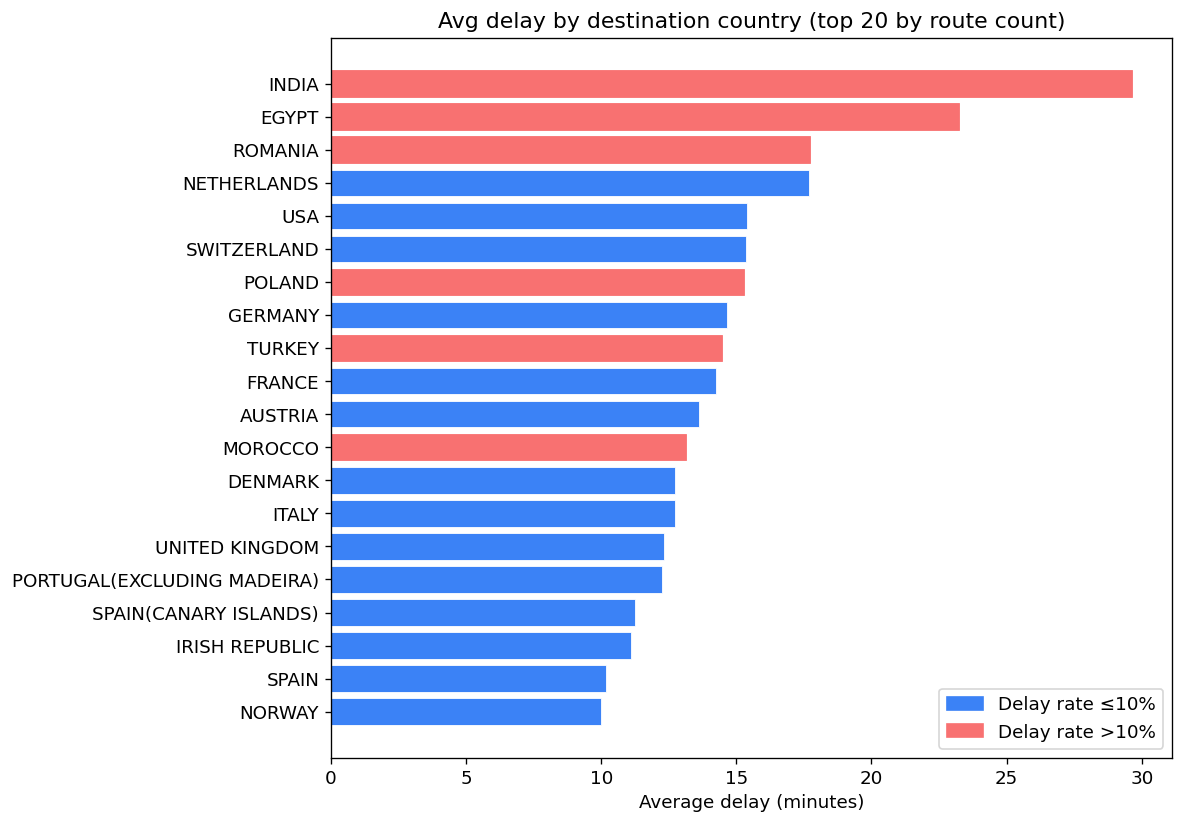

In [9]:
country_stats = df.groupby("origin_destination_country").agg(
    routes=("is_delayed", "size"),
    delay_rate=("is_delayed", "mean"),
    avg_delay=("average_delay_mins", "mean"),
).sort_values("routes", ascending=False)

top20 = country_stats.head(20).sort_values("avg_delay")

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20.index, top20["avg_delay"], color="#3b82f6", edgecolor="white", linewidth=0.5)

# Highlight high delay-rate countries
for bar, (_, row) in zip(bars, top20.iterrows()):
    if row["delay_rate"] > 0.1:
        bar.set_color("#f87171")

ax.set_xlabel("Average delay (minutes)")
ax.set_title("Avg delay by destination country (top 20 by route count)")

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#3b82f6", label="Delay rate ≤10%"),
    Patch(color="#f87171", label="Delay rate >10%"),
], loc="lower right")

plt.tight_layout()
plt.show()

## Cancellation vs delay relationship

Do routes with higher cancellation rates also tend to have more delays?

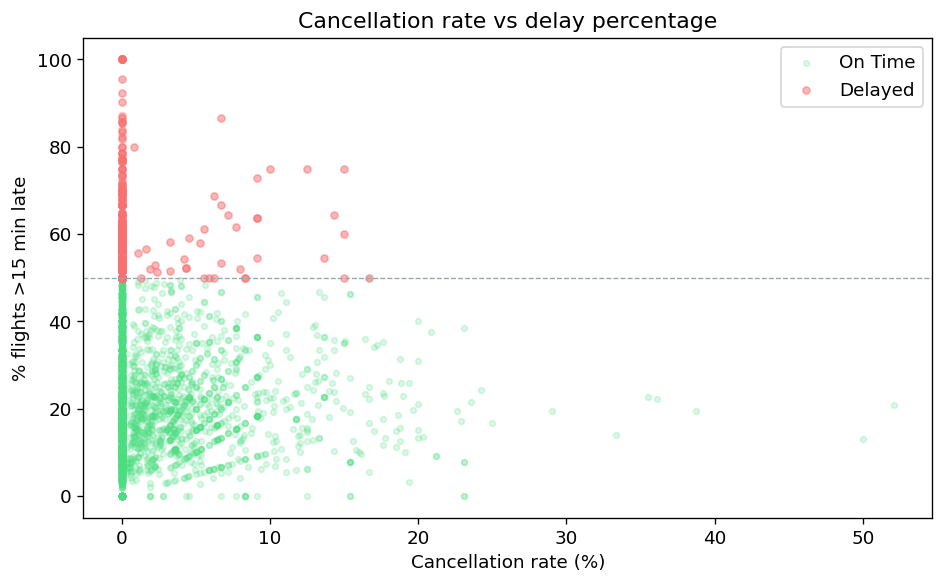

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

delayed = df[df["is_delayed"] == 1]
on_time = df[df["is_delayed"] == 0]

ax.scatter(on_time["flights_cancelled_percent"], on_time["late_percent"],
           alpha=0.2, s=12, color="#4ade80", label="On Time")
ax.scatter(delayed["flights_cancelled_percent"], delayed["late_percent"],
           alpha=0.5, s=18, color="#f87171", label="Delayed")

ax.set_xlabel("Cancellation rate (%)")
ax.set_ylabel("% flights >15 min late")
ax.set_title("Cancellation rate vs delay percentage")
ax.axhline(50, color="#94a3b8", linestyle="--", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

## Delay breakdown heatmap — airport × delay bucket

How are flights distributed across delay buckets at each airport?

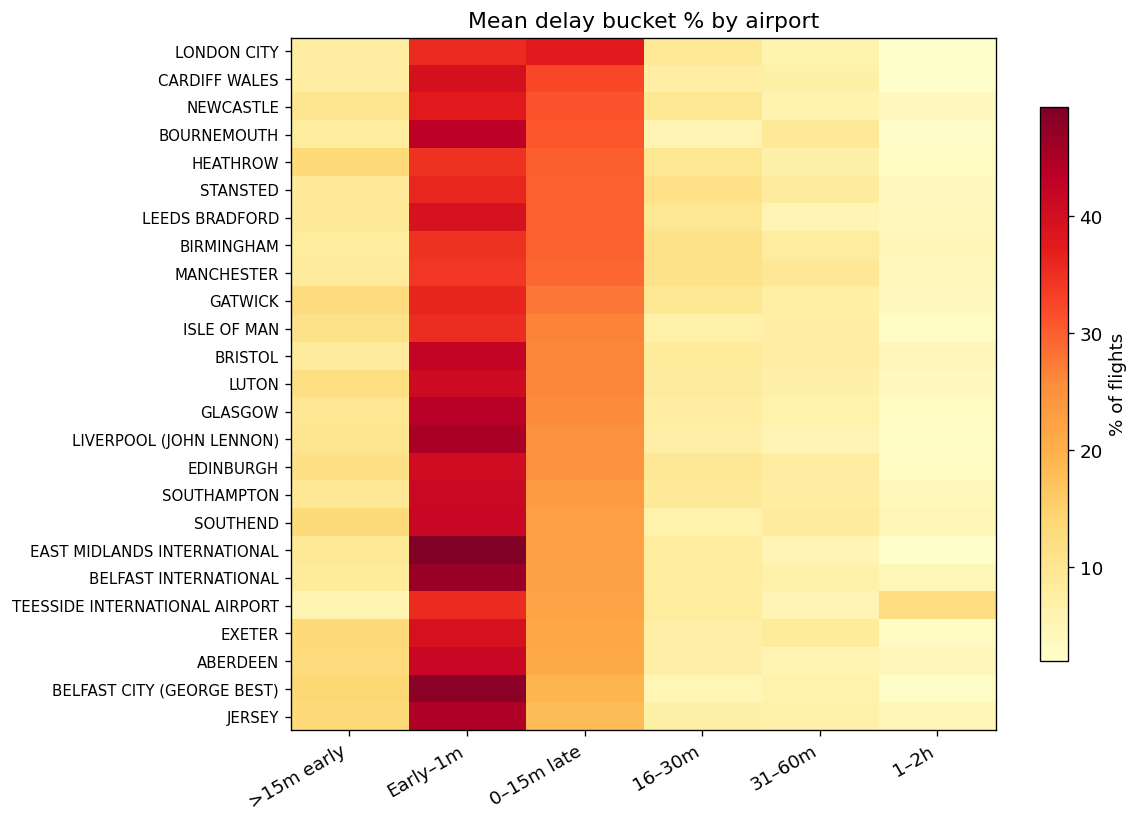

In [11]:
bucket_cols = [
    "flights_more_than_15_minutes_early_percent",
    "flights_15_minutes_early_to_1_minute_early_percent",
    "flights_0_to_15_minutes_late_percent",
    "flights_between_16_and_30_minutes_late_percent",
    "flights_between_31_and_60_minutes_late_percent",
    "flights_between_61_and_120_minutes_late_percent",
]
bucket_labels = [">15m early", "Early–1m", "0–15m late", "16–30m", "31–60m", "1–2h"]

heatmap_data = df.groupby("reporting_airport")[bucket_cols].mean()
heatmap_data.columns = bucket_labels
heatmap_data = heatmap_data.sort_values("0–15m late", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="YlOrRd")

ax.set_xticks(range(len(bucket_labels)))
ax.set_xticklabels(bucket_labels, rotation=30, ha="right")
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)
ax.set_title("Mean delay bucket % by airport")

fig.colorbar(im, ax=ax, label="% of flights", shrink=0.8)
plt.tight_layout()
plt.show()

## Flight volume vs delay rate

Do low-volume routes tend to be noisier/more delayed?

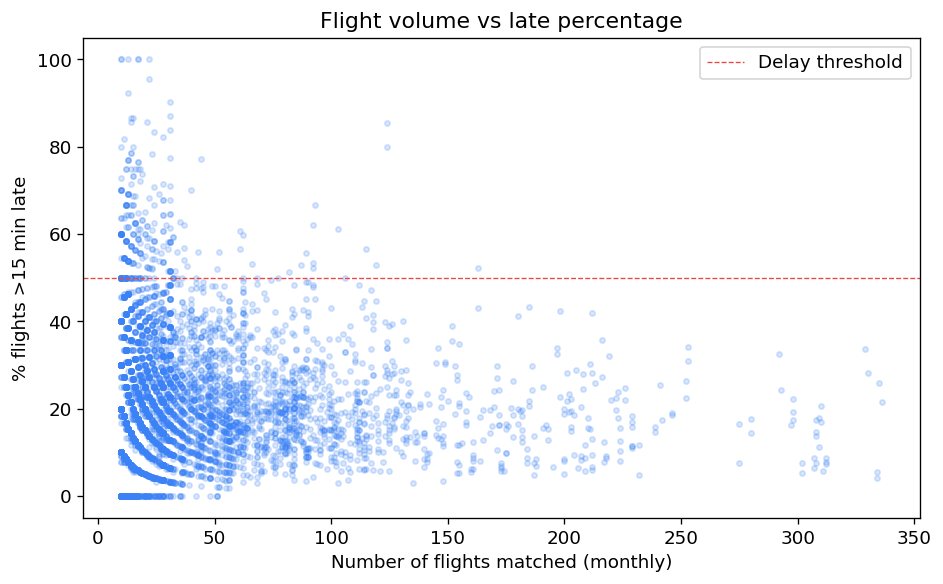

Correlation: -0.099


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df["number_flights_matched"], df["late_percent"],
           alpha=0.2, s=10, color="#3b82f6")
ax.set_xlabel("Number of flights matched (monthly)")
ax.set_ylabel("% flights >15 min late")
ax.set_title("Flight volume vs late percentage")
ax.axhline(50, color="#ef4444", linestyle="--", linewidth=0.8, label="Delay threshold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Correlation: {df['number_flights_matched'].corr(df['late_percent']):.3f}")

## Missing data

Where are the nulls? This informs feature engineering choices.

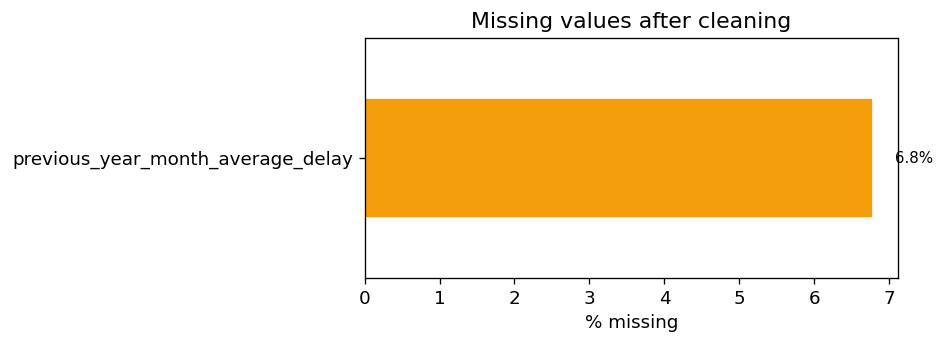

In [13]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

if len(null_pct) == 0:
    print("No missing values after cleaning.")
else:
    fig, ax = plt.subplots(figsize=(8, 3))
    null_pct.plot.barh(ax=ax, color="#f59e0b", edgecolor="white")
    ax.set_xlabel("% missing")
    ax.set_title("Missing values after cleaning")
    for i, v in enumerate(null_pct.values):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()